# One official locked-TEST evaluation

The final procedure was frozen, committed at 7922527d9599567887de2a5836e84a4e7e89458e, pushed, and CI-passing before TEST was unlocked. The exact frozen combined TF-IDF plus balanced Logistic Regression pipeline was freshly fitted on all TRAIN+VALIDATION rows (47,615). One official metric set was produced on the untouched 12,284-row TEST split. This notebook reads persisted aggregate results only: it never loads TEST CSVs, a model artifact, or row-level predictions, and it does not run the evaluation pipeline.

Macro-F1 was fixed as the primary metric before TEST. The observed result is accepted without tuning or comparing a second TEST model.

In [1]:
from pathlib import Path
import json
import hashlib
import pandas as pd
from IPython.display import display, Image, Markdown

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'reports' / 'final_test_metrics.json').is_file())
metrics_path = root / 'reports' / 'final_test_metrics.json'
payload = json.loads(metrics_path.read_text(encoding='utf-8'))
manifest = json.loads((root / 'reports' / 'final_evaluation_manifest.json').read_text(encoding='utf-8'))
assert hashlib.sha256(metrics_path.read_bytes()).hexdigest() == manifest['final_metrics_sha256']
assert payload['pretest_commit_sha'] == manifest['pretest_commit_sha']
assert manifest['evaluation_completed']
display({'pretest_commit': payload['pretest_commit_sha'],
         'train_rows': payload['train_rows'],
         'validation_rows': payload['validation_rows'],
         'development_rows': payload['development_rows'],
         'test_rows': payload['test_rows'],
         'official_prediction_vectors': manifest['official_prediction_vectors']})

{'pretest_commit': '7922527d9599567887de2a5836e84a4e7e89458e',
 'train_rows': 45615,
 'validation_rows': 2000,
 'development_rows': 47615,
 'test_rows': 12284,
 'official_prediction_vectors': 1}

## Official TEST metrics

The three classes are ordered negative, neutral, positive. Per-class support and the confusion matrix cells sum to 12,284. These are benchmark results for historical tweets, not an estimate for current brand-specific comments.

,metric,value
0,accuracy,0.622761
1,macro_precision,0.614583
2,macro_recall,0.630908
3,macro_f1,0.619917
4,weighted_f1,0.622317


,sentiment,precision,recall,f1,support
0,negative,0.594525,0.694361,0.640576,3972
1,neutral,0.670996,0.574364,0.618931,5937
2,positive,0.578229,0.624000,0.600243,2375


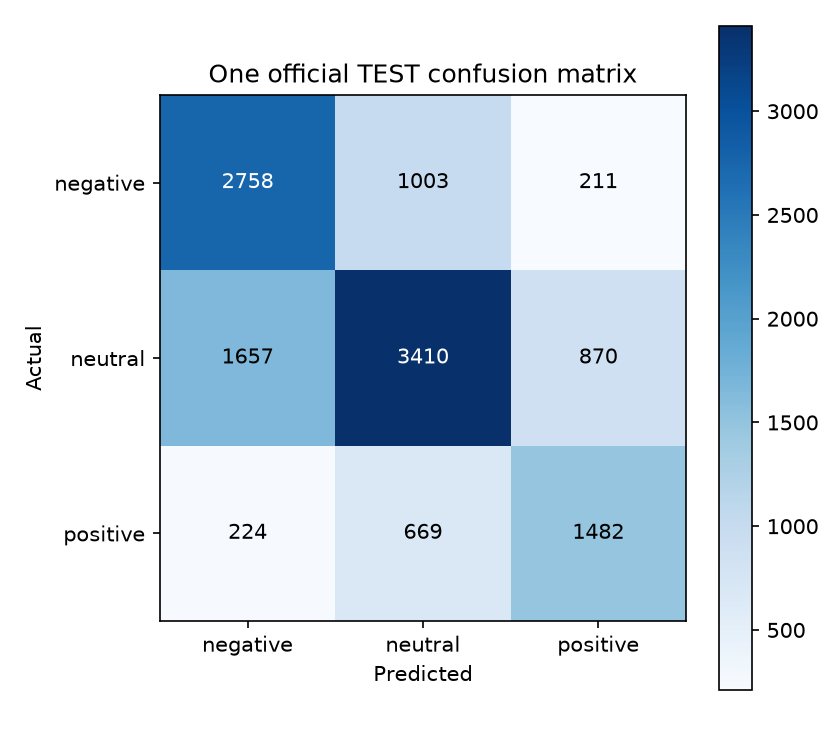

{'confusion_matrix': [[2758, 1003, 211], [1657, 3410, 870], [224, 669, 1482]]}

In [2]:
m = payload['test_metrics']
display(pd.DataFrame([{'metric': key, 'value': m[key]} for key in
                      ('accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'weighted_f1')]))
display(pd.DataFrame([{'sentiment': label, **m['per_class'][label]} for label in
                      ('negative', 'neutral', 'positive')]))
display(Image(filename=str(root / 'reports' / 'figures' / 'final_test_confusion_matrix.png')))
display({'confusion_matrix': m['confusion_matrix']})

## VALIDATION versus TEST

VALIDATION measured the TRAIN-only development candidate. TEST measured the identical frozen configuration after the authorized TRAIN+VALIDATION refit. Differences are descriptive. The lower TEST macro-F1 and positive-class F1 do not trigger a model change.

In [3]:
v = payload['frozen_validation_metrics']
rows = []
for title, key, label in [('Accuracy', 'accuracy', None), ('Macro-F1', 'macro_f1', None),
                          ('Negative F1', 'f1', 'negative'), ('Neutral F1', 'f1', 'neutral'),
                          ('Positive F1', 'f1', 'positive')]:
    before = v[key] if label is None else v['per_class'][label][key]
    after = m[key] if label is None else m['per_class'][label][key]
    rows.append({'metric': title, 'validation': before, 'test': after,
                 'test_minus_validation': after - before})
display(pd.DataFrame(rows).round(4))

,metric,validation,test,test_minus_validation
0,Accuracy,0.6925,0.6228,-0.0697
1,Macro-F1,0.6728,0.6199,-0.0529
2,Negative F1,0.5850,0.6406,0.0556
3,Neutral F1,0.6861,0.6189,-0.0672
4,Positive F1,0.7475,0.6002,-0.1473


## Procedure, safeguards and limitations

The manifest records the pre-TEST SHA, the final model and metrics checksums, and the processed TEST checksum. The final saved estimator was reloaded and its predictions matched the original vector; that technical check was not scored a second time. The default evaluation command only points to the persisted result, and the manifest blocks another official evaluation. No raw TEST examples or row-level predictions are published.

Historical English tweets, sarcasm, missing conversational context, ambiguous annotation, class imbalance and modern brand-domain shift remain. The model is not a substitute for human moderation or psychological inference. Next work concerns a reusable inference service and separate real-world validation, not retuning on this TEST split.

In [4]:
display(Markdown((root / 'reports' / 'final_evaluation_summary.md').read_text(encoding='utf-8')))
display(Markdown((root / 'models' / 'final' / 'MODEL_CARD.md').read_text(encoding='utf-8')))

# One official locked-TEST sentiment evaluation

Pre-TEST procedure commit: 7922527d9599567887de2a5836e84a4e7e89458e. Protocol version: 1.0.
The frozen combined TF-IDF plus Logistic Regression procedure was fitted once on TRAIN+VALIDATION, then evaluated once on untouched TEST. No competing model or TEST-driven tuning was performed.

Fit rows: TRAIN 45,615 + VALIDATION 2,000 = 47,615. TEST rows: 12,284.
Final fitting took 23.76 seconds; one official prediction took 1.62 seconds.

## Official TEST metrics

Accuracy 0.6228; macro precision 0.6146; macro recall 0.6309; **macro-F1 0.6199**; weighted F1 0.6223.

| Class | Precision | Recall | F1 | Support |
|---|---:|---:|---:|---:|
| negative | 0.5945 | 0.6944 | 0.6406 | 3,972 |
| neutral | 0.6710 | 0.5744 | 0.6189 | 5,937 |
| positive | 0.5782 | 0.6240 | 0.6002 | 2,375 |

Confusion rows are actual and columns predicted, ordered negative, neutral, positive:

[[2758, 1003, 211], [1657, 3410, 870], [224, 669, 1482]]

## Descriptive VALIDATION versus TEST

| Metric | VALIDATION | TEST | TEST − VALIDATION |
|---|---:|---:|---:|
| Accuracy | 0.6925 | 0.6228 | -0.0697 |
| Macro-F1 | 0.6728 | 0.6199 | -0.0529 |
| Negative F1 | 0.5850 | 0.6406 | +0.0556 |
| Neutral F1 | 0.6861 | 0.6189 | -0.0672 |
| Positive F1 | 0.7475 | 0.6002 | -0.1473 |

The VALIDATION score belongs to the development candidate fitted on TRAIN only. The TEST score belongs to the same frozen configuration refitted on TRAIN+VALIDATION. This gap is descriptive, not a basis for changing the model.

## Artifact and safeguards

Final fitted artifact: models/final/final_model.joblib; 4,418,974 bytes; SHA-256 a3e375cc0e75c68f2ac8de8a35d46369e566c3e0821d31c778018f4edc83451e. Reloaded predictions matched the original vector exactly. The second prediction call is solely an artifact-integrity comparison; no second metric set was calculated.
The label-only prediction file is kept locally under data/processed and excluded from Git. No raw TEST tweet examples appear in this report.
An evaluation manifest blocks accidental reruns. The recorded pre-TEST commit was pushed and CI-passing before TEST was unlocked.

## Limits and next work

TweetEval contains historical English tweets. Sarcasm, missing context, annotation ambiguity, class imbalance and modern brand-domain shift limit real-world use. This benchmark result is not a guarantee for current brand comments or psychological inference. No post-TEST parameter, preprocessing or model changes were made. Next: build a reusable inference service, then evaluate responsibly on real public social-media data and design aggregate analytics.


# Final TweetEval sentiment model card

## Intended use

A research baseline for three-class sentiment on TweetEval-style English posts and a starting point for later brand-monitoring evaluation. It is not a substitute for human moderation and is not suitable for psychological inference.

## Dataset and training

Cardiff NLP TweetEval sentiment, pinned source revision recorded in data/raw/manifest.json. Official TRAIN (45,615) and VALIDATION (2,000) rows were combined after model selection, giving 47,615 final fitting rows. No deduplication, resplitting or resampling. One official TEST evaluation used 12,284 untouched rows.

## Frozen pipeline

Deterministic preprocessing with targeted escaped-punctuation normalization; word (1,2) and char_wb (3,5) TF-IDF; word weight 1.0 and character weight 1.25; balanced Logistic Regression (C=1, lbfgs, max_iter=350, seed 42). Exact parameters and environment are in final_model_metadata.json.

## One official TEST result

Accuracy 0.6228; macro precision 0.6146; macro recall 0.6309; macro-F1 0.6199; weighted F1 0.6223.

| Class | Precision | Recall | F1 | Support |
|---|---:|---:|---:|---:|
| negative | 0.5945 | 0.6944 | 0.6406 | 3,972 |
| neutral | 0.6710 | 0.5744 | 0.6189 | 5,937 |
| positive | 0.5782 | 0.6240 | 0.6002 | 2,375 |

## Limits and ethics

Historical tweets may not transfer to modern, brand-specific comments. Sarcasm, short or missing context, mixed sentiment, annotation ambiguity and class imbalance remain. Do not treat labels as objective psychological facts. Future collection should respect platform terms and avoid unnecessary personal information. Raw/processed dataset CSVs and row-level TEST predictions are not published. Check upstream dataset rights before redistribution.

Pre-TEST procedure commit: 7922527d9599567887de2a5836e84a4e7e89458e. No tuning followed the TEST result.
